##                       classification project : credit risk analysis

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/credit_risk_dataset.csv")
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


**Display Basic info**

In [ ]:
df.shape
print("no of rows:",df.shape[0])
print("no of column:",df.shape[1])

no of rows: 32581
no of column: 12


In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [ ]:
df.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## Missing value Handling

In [ ]:
# check missing value

df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
df=df.drop('person_age',axis=1)
df

,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...
32576,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [ ]:
# fillna()
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [ ]:
df[['person_emp_length','loan_int_rate']].isnull().sum()

,0
person_emp_length,0
loan_int_rate,0


### Data preprocessing

In [ ]:
#encoding
# Handling categorical data

intent_map={'PERSONAL': 0,'EDUCATION': 1,'VENTURE': 2,'MEDICAL': 3,'DEBTCONSOLIDATION': 4,'HOMEIMPROVEMENT': 5}
df['loan_intent']=df['loan_intent'].map(intent_map)

In [ ]:
grade_map={"A":1, "B":2, "C":3, "D":4, "E":5, "F":6, "G":7}
df['loan_grade']=df['loan_grade'].map(grade_map)

In [ ]:
home_map={"RENT":0, "OWN":1, "MORTGAGE":2, "OTHER":3}
df['person_home_ownership']=df['person_home_ownership'].map(home_map)

In [ ]:
df['cb_person_default_on_file']=df['cb_person_default_on_file'].map({"Y":1,"N":0})

In [ ]:
df['loan_intent'].value_counts()

,count
loan_intent,
1,6453
3,6071
2,5719
0,5521
4,5212
5,3605


In [ ]:
df['person_home_ownership'].value_counts()

,count
person_home_ownership,
0,16446
2,13444
1,2584
3,107


In [ ]:
df['loan_grade'].value_counts()

,count
loan_grade,
1,10777
2,10451
3,6458
4,3626
5,964
6,241
7,64


In [ ]:
df['cb_person_default_on_file'].value_counts()

,count
cb_person_default_on_file,
0,26836
1,5745


In [ ]:
# separate features and target

x=df.drop("loan_status",axis=1)
x

,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,59000,0,123.0,0,4,35000,16.02,0.59,1,3
1,9600,1,5.0,1,2,1000,11.14,0.10,0,2
2,9600,2,1.0,3,3,5500,12.87,0.57,0,3
3,65500,0,4.0,3,3,35000,15.23,0.53,0,2
4,54400,0,8.0,3,3,35000,14.27,0.55,1,4
...,...,...,...,...,...,...,...,...,...,...
32576,53000,2,1.0,0,3,5800,13.16,0.11,0,30
32577,120000,2,4.0,0,1,17625,7.49,0.15,0,19
32578,76000,0,3.0,5,2,35000,10.99,0.46,0,28
32579,150000,2,5.0,0,2,15000,11.48,0.10,0,26


In [ ]:
y=df['loan_status']
y

,loan_status
0,1
1,0
2,1
3,1
4,1
...,...
32576,0
32577,0
32578,1
32579,0


In [ ]:
# split the data  80% and 20%


from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## Feature scaling

In [ ]:
#scaling


from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [ ]:
x_test

array([[-0.68465096,  0.08982244,  0.28987743, ...,  1.80079234,
        -0.47385615, -0.92530173],
       [-0.03064606, -0.94991617, -1.13301827, ..., -0.08717016,
         2.11034511,  1.0464767 ],
       [ 0.11468836,  1.12956105,  1.23847456, ...,  0.47921859,
        -0.47385615, -0.67882943],
       ...,
       [ 0.87769408,  1.12956105, -0.18442114, ..., -0.74795703,
        -0.47385615, -0.92530173],
       [ 0.62335884,  1.12956105, -0.89586899, ..., -1.03115141,
        -0.47385615, -0.67882943],
       [ 0.11468836,  0.08982244,  0.28987743, ...,  1.70639422,
        -0.47385615,  0.55353209]])

## Model creation

In [ ]:
# train all classification models

from sklearn.linear_model import LogisticRegression
l_model=LogisticRegression()

In [ ]:
from sklearn.naive_bayes import GaussianNB
n_model=GaussianNB()

In [ ]:
from sklearn.svm import SVC
s_model=SVC()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
r_model=RandomForestClassifier(n_estimators=150,random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
k_model=KNeighborsClassifier(n_neighbors=5)


In [ ]:
models=[l_model,n_model,s_model,k_model,r_model]

### preformance evaluation

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [ ]:
# accuracy score all models

model_name=[]
accuracy_scores=[]
for model  in models:
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  score=accuracy_score(y_test,y_pred)
  print(model,"accuracy score:",score)
  print("*"*50)
  model_name.append(model.__class__.__name__)
  accuracy_scores.append(score)


LogisticRegression() accuracy score: 0.8396501457725948
**************************************************
GaussianNB() accuracy score: 0.8005217124443762
**************************************************
SVC() accuracy score: 0.8988798526929569
**************************************************
KNeighborsClassifier() accuracy score: 0.8922817247199631
**************************************************
RandomForestClassifier(n_estimators=150, random_state=42) accuracy score: 0.9094675464170631
**************************************************


<function matplotlib.pyplot.show(close=None, block=None)>

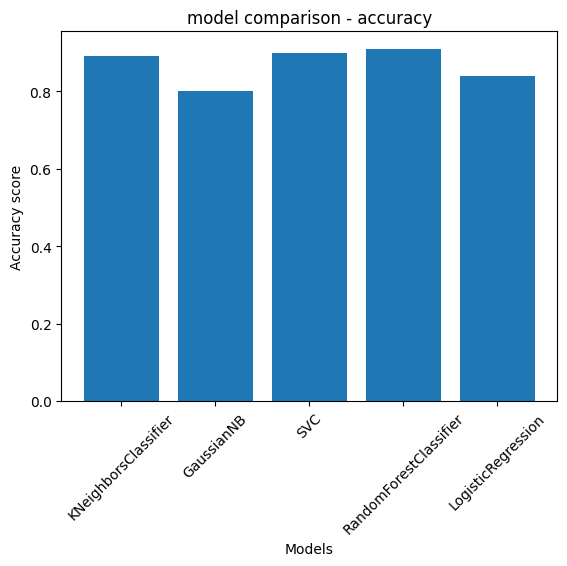

In [ ]:
# plot bar chart

plt.bar(model_name,accuracy_scores)
plt.xlabel("Models")
plt.ylabel("Accuracy score")
plt.title("model comparison - accuracy")
plt.xticks(rotation=45)
plt.show

In [ ]:
#model creation



from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=150,random_state=42)
model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=150, random_state=42)

In [ ]:
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:

ap=pd.DataFrame({"actual_value":y_test,"predicted_value":y_pred})
ap

,actual_value,predicted_value
14668,0,0
24614,0,0
11096,0,0
10424,1,1
26007,1,1
...,...,...
31330,0,0
2862,0,0
14754,0,0
14170,0,0


In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy


0.9094675464170631

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[4881,  191],
       [ 399, 1046]])

In [ ]:
y_pred=model.predict([[9600	,1,	5.0	,1,	2	,1000	,11.14	,0.10	,0,2]])
y_pred

array([1])

In [ ]:
y_pred=model.predict([[54400,0	,8.0,	3,3,35000	,14.27,0.55,1,4]])
y_pred

array([0])

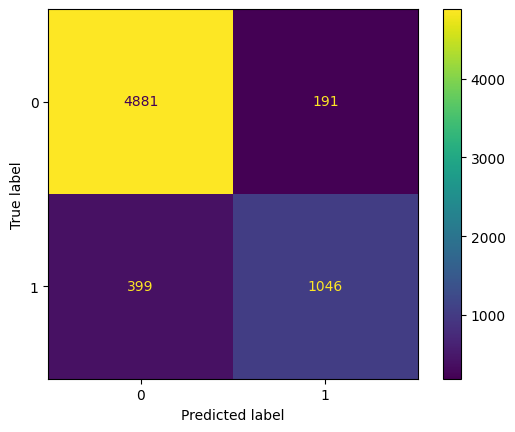

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

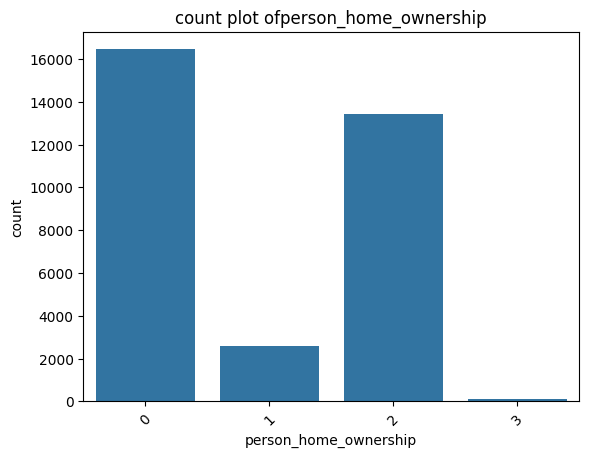

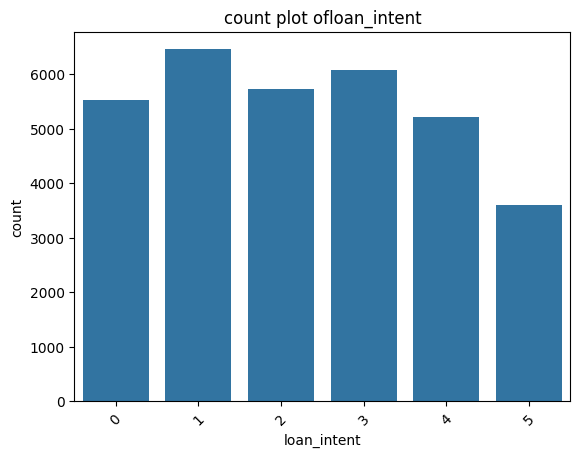

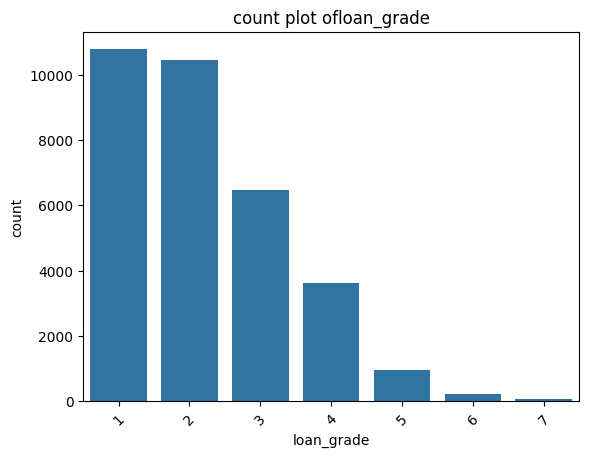

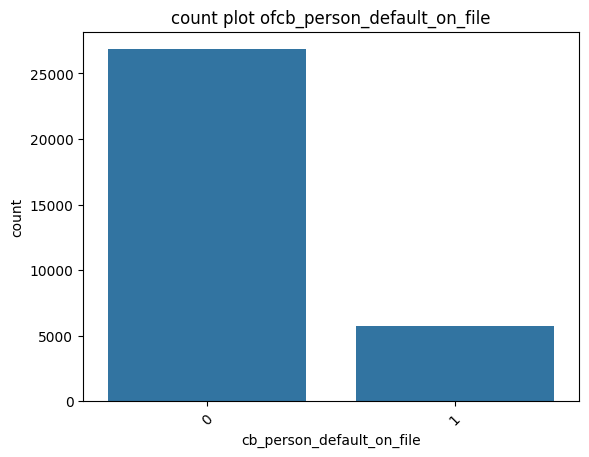

In [ ]:
# Barplots for Categorical columns


categorical_col=["person_home_ownership","loan_intent","loan_grade","cb_person_default_on_file"]
for col in categorical_col:
  sns.countplot(x=df[col])
  plt.title("count plot of"+col)
  plt.xticks(rotation=45)
  plt.show()

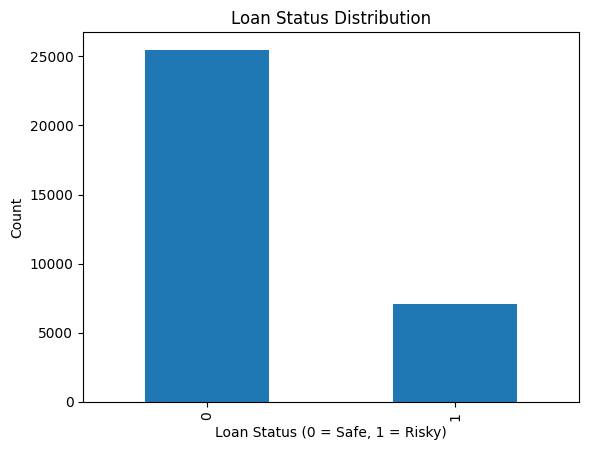

In [ ]:
# Count of safe vs risky loans
df['loan_status'].value_counts().plot(kind='bar')
plt.xlabel('Loan Status (0 = Safe, 1 = Risky)')
plt.ylabel('Count')
plt.title('Loan Status Distribution')
plt.show()

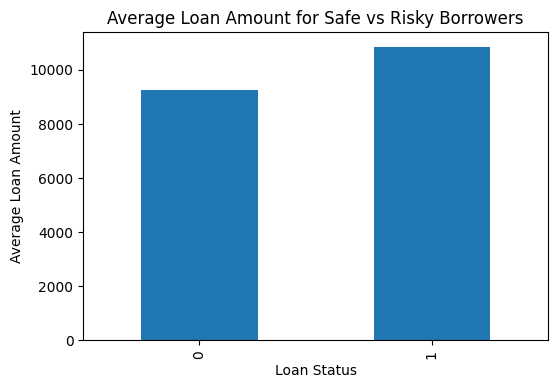

In [ ]:
# count for average loan amount

plt.figure(figsize=(6,4))
df.groupby('loan_status')['loan_amnt'].mean().plot(kind='bar')
plt.xlabel("Loan Status")
plt.ylabel("Average Loan Amount")
plt.title("Average Loan Amount for Safe vs Risky Borrowers")
plt.show()

/tmp/ipython-input-1744878677.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


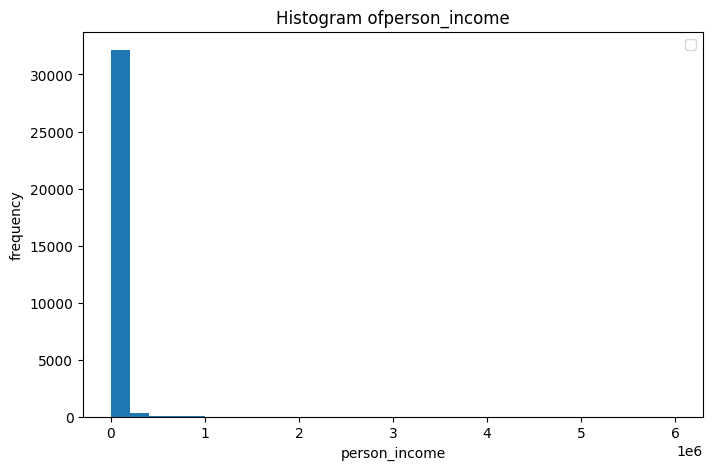

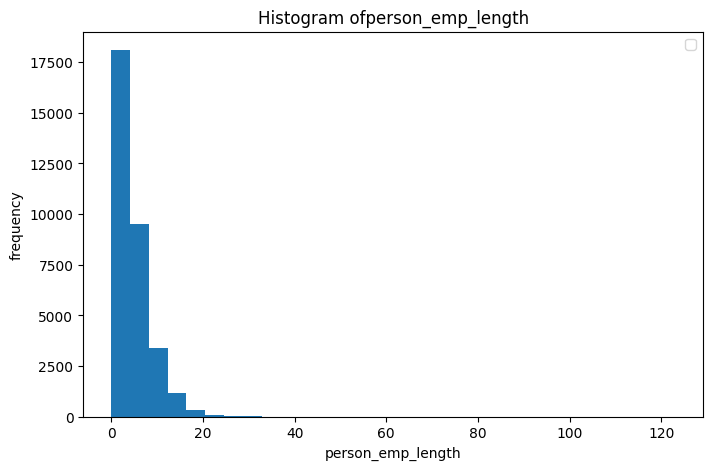

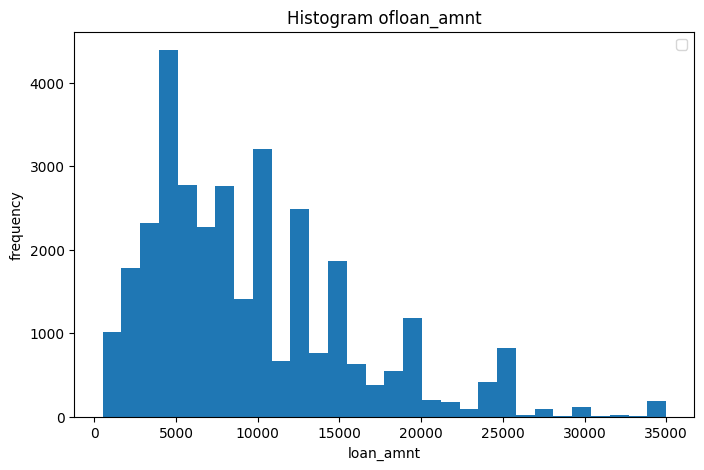

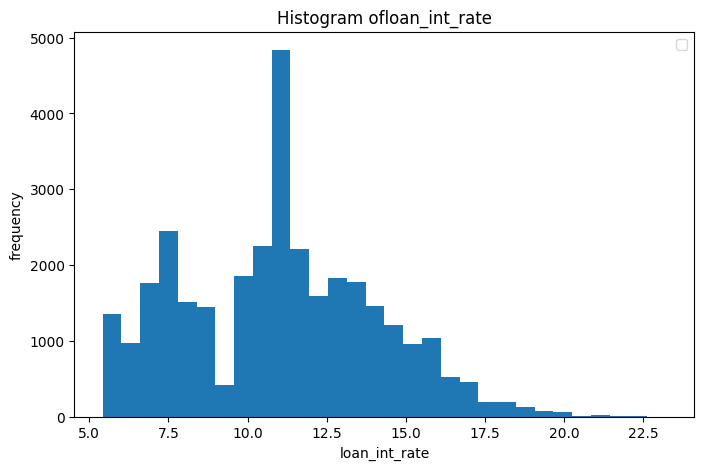

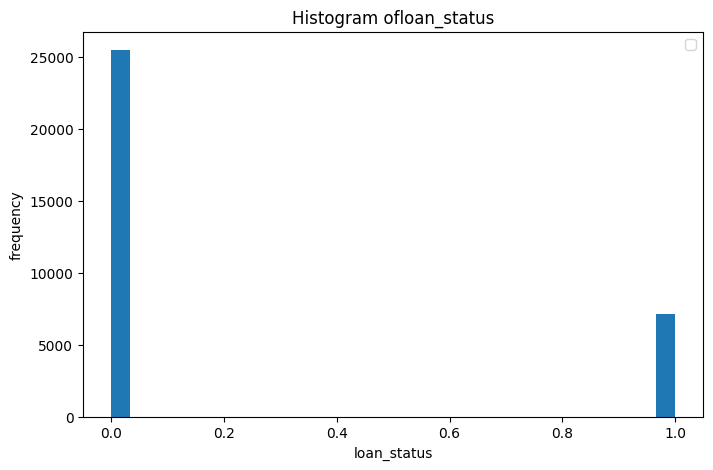

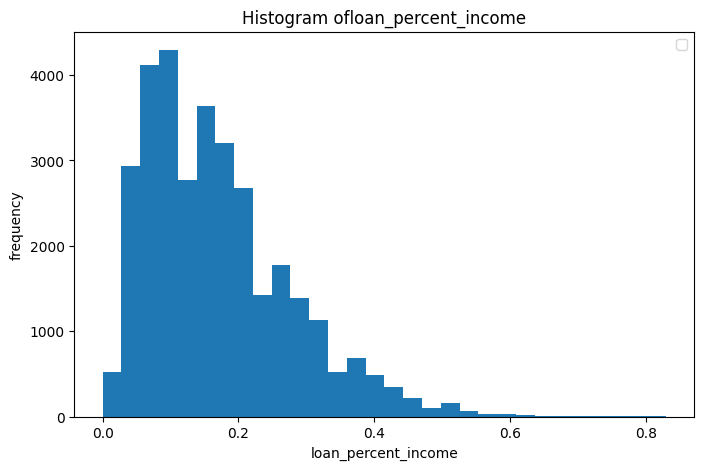

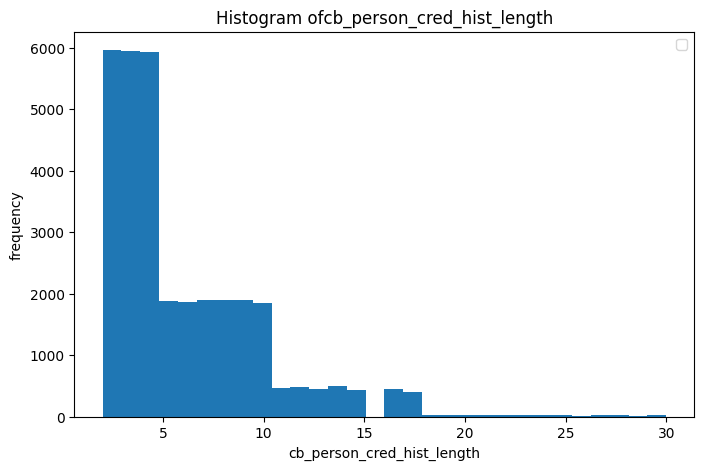

In [ ]:
# HIstograms for NUMERICAL columns

numerical_cols=["person_income","person_emp_length","loan_amnt","loan_int_rate","loan_status","loan_percent_income","cb_person_cred_hist_length"]


for col in numerical_cols:
  plt.figure(figsize=(8,5))
  plt.hist(df[col].dropna(),bins=30)
  plt.xlabel(col)
  plt.ylabel("frequency")
  plt.title("Histogram of" +col)
  plt.legend()
  plt.show()